# CAB420, Practical 2 - Template

**Note, as the three questions in this weeks practical build on one another, all solutions are in the one script**

## Problem 1. Overfitting Linear Regression
In the week 1 practical, you developed a model to predict cyclist counts at a single counter. Using the same data and starting from the initial model before terms were removed, overcomplicate it such that it overfits to the training data. The easiest way to do this is by including a large number of higher order (i.e. interaction, quadratic and higher order polynomial) terms.

Verify that the model has overfit through evaluating on the validation and testing datasets, and compare it's performance to the simple model that you started with.

## Problem 2. Ridge Regression
Apply ridge regression to your two models (the simple model from Week 1, and the overfitting model from Problem 1 of this week). Using the validation set, select the best value of $\lambda$ for each model. For the selected model:
* Compute the $R^2$ and adjusted $R^2$, and draw a qqplot to assess the models validity;
* Compute the RMSE on the test set and compare the performance with the linear models.

## Problem 3. Lasso Regression
Apply lasso regression to your two models (the simple model from Week 1, and the overfitting model from Problem 1 of this week). Using the validation set, select the best value of $\lambda$ for each model. For the selected model:
* Compute the $R^2$ and adjusted $R^2$ (make sure to consider how many terms are removed by lasso), and draw a qqplot to assess the models validity;
* Compute the RMSE on the test set and compare the performance with the linear models and the ridge regression models.

### Relevant Examples

The second linear regression example, ``CAB420_Regression_Example_2_Regularised_Regression.ipynb`` is a useful starting point here. You may also find the third linear regression example, ``CAB420_Regression_Example_3_Regression_with_Less_Data.ipynb`` of use, however this contains the same relvant code (fitting linear and regularised regression).

### Suggested Packages

The following packages are suggested, however there are many ways to approach things in python, if you'd rather use different pacakges that's cool too.

In particular with this pratical, you have a choice of whether you'd rather use sklearn or statsmodels for regression.

In [2]:
# import all the important packages

# numpy handles pretty much anything that is a number/vector/matrix/array
import numpy as np
# pandas handles dataframes (exactly the same as tables in Matlab)
import pandas as pd
# matplotlib emulates Matlabs plotting functionality
import matplotlib.pyplot as plt
# seaborn, because of excellent heatmaps
import seaborn as sns;
# stats models is a package that is going to perform the regression analysis
from statsmodels import api as sm
from scipy import stats
from sklearn.metrics import mean_squared_error, r2_score
# can also use sklearn for our regression
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.preprocessing import PolynomialFeatures
# os allows us to manipulate variables on out local machine, such as paths and environment variables
import os
# self explainatory, dates and times
from datetime import datetime, date
# a helper package to help us iterate over objects
import itertools

### Step 1: Load and Pre-process the data

Loading and pre-processing should follow the same process as the previous practical. This should:
* load the data
* split into train, validation and test and pull out X and Y arrays

In this practical we also seek to overcomplicate our model, i.e. add higher order terms, etc, such that it overfits. To achieve this you could:
* Use ``PolynomialFeatures`` which has been imported from ``sklearn.preprocessing``; or
* Use the x2fx function below which replicates a similar function is MATLAB and provides a handy way of adding higher order terms.

Maintain the original (unexpanded) copy of the data as a separate variable as well as the "blown up" version.

You should also consider the issue of data standardisation. This will be useful for the regularised regression and should be done prior to Questions 2 and 3; but you may also wish to do this here such that you are using the same data throughout. A function for standardisation is provided below.

In [3]:
def x2fx(x, model='quadratic'):
  """Will create a quadratic, interaction and linear
  versions of our variable of interest

  Similar to the `x2fx()` function in Matlab.

  Written by Saullo G. P. Castro, from
  https://stackoverflow.com/questions/26574998/is-there-an-equivalent-function-for-x2fx-in-numpy

  Basically don't worry too much about how this func works. If I had to write it myself,
  it would look a lot worse than this.

  Args:
    x (np.array):
      Data set with columns as features (variables) that we 
      want to generate higher order terms for
    model (str):
      Determine linear, interaction, quadratic, purequadratic terms
 
  Returns:
    Array with higher order terms added as additional columns
  """
  from itertools import combinations as comb
  linear = np.c_[np.ones(x.shape[0]), x]
  if model == 'linear':
    return linear
  if model == 'purequadratic':
    return np.c_[linear, x**2]

  interaction = np.vstack([x[:,i]*x[:,j] for i, j in
                           comb(range(x.shape[1]), 2)]).T
    
  if model == 'interaction':
    return np.c_[linear, interaction]
  if model == 'quadratic':
    return np.c_[linear, interaction, x**2]

def standardise(data):
  """ Standardise/Normalise data to have zero mean and unit variance

  Args:
    data (np.array):
      data we want to standardise (usually covariates)

    Returns:
      Standardised data, mean of data, standard deviation of data
  """
  mu = np.mean(data, axis=0)
  sigma = np.std(data, axis=0)
  scaled = (data - mu) / sigma
  return scaled, mu, sigma

In [40]:
##Data from Prac 1
combined = pd.read_csv('combined (1).csv')
combined['Date'] = pd.to_datetime(combined['Date'], format='mixed', dayfirst=True)


# we have 1826 rows and 57 columns
# we need to remove rows with lots of na values, first determine the threshold based on the number of rows
threshold = combined.shape[0] - 300
combined_filtered = combined.dropna(axis=1, thresh=threshold)
print(combined_filtered.shape)
combined_filtered = combined_filtered.dropna(axis = 0)
print(combined_filtered.shape)
combined_filtered.head()

#Train, Test, Val
train = combined_filtered[combined_filtered.Date < datetime(year=2017, month=1, day=1)]
val = combined_filtered[((combined_filtered.Date >= datetime(year=2017, month=1, day=1)) &
                        (combined_filtered.Date < datetime(year=2018, month=1, day=1)))]
test = combined_filtered[((combined_filtered.Date >= datetime(year=2018, month=1, day=1)) &
                          (combined_filtered.Date < datetime(year=2019, month=1, day=1)))]
print('num train = {}'.format(train.shape[0]))
print('val train = {}'.format(val.shape[0]))
print('test train = {}'.format(test.shape[0]))

## I want to see the data as a csv
training_data = pd.DataFrame(train)
training_data.to_csv('training_data.csv')

# 1. Exact names based on the CSV
X_bom = [
    'RainfallAmount_millimetres_', 
    'DailyGlobalSolarExposure_MJ_m_m_', 
    'MaximumTemperature_DegreeC_'
]

# 2. Fix the space in the search string!
x_bbc = [x for x in train.columns.values if "CyclistsInbound" in x]

# Remove the target variable
target = 'BicentennialBikewayCyclistsInbound'
if target in x_bbc:
    x_bbc.remove(target)

X_variables = X_bom + x_bbc

# 3. Create CLEAN X and Y arrays (NO sm.add_constant here!)
Y_train = np.array(train[target], dtype=np.float64)
X_train = np.array(train[X_variables], dtype=np.float64)

Y_val = np.array(val[target], dtype=np.float64)
X_val = np.array(val[X_variables], dtype=np.float64)

Y_test = np.array(test[target], dtype=np.float64)
X_test = np.array(test[X_variables], dtype=np.float64)

# 4. Create the Overfitted/Complex versions
# x2fx handles adding the constant automatically
X_train_complex = x2fx(X_train)
X_val_complex = x2fx(X_val)
X_test_complex = x2fx(X_test)

print("Train shape:", X_train_complex.shape)
print("Val shape:", X_val_complex.shape)
print("Test shape:", X_test_complex.shape)

Task was destroyed but it is pending!
task: <Task pending name='Task-663' coro=<_async_in_context.<locals>.run_in_context() done, defined at /Users/jessie.bowness/venvs/cab420_venv/lib/python3.12/site-packages/ipykernel/utils.py:57> wait_for=<Task pending name='Task-664' coro=<Kernel.shell_main() running at /Users/jessie.bowness/venvs/cab420_venv/lib/python3.12/site-packages/ipykernel/kernelbase.py:597> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at /Users/jessie.bowness/venvs/cab420_venv/lib/python3.12/site-packages/zmq/eventloop/zmqstream.py:563]>
/usr/local/Cellar/python@3.12/3.12.12_2/Frameworks/Python.framework/Versions/3.12/lib/python3.12/collections/__init__.py:449: RuntimeWarning: coroutine 'Kernel.shell_main' was never awaited
  result = tuple_new(cls, iterable)
Task was destroyed but it is pending!
task: <Task pending name='Task-664' coro=<Kernel.shell_main() running at /Users/jessie.bowness/venvs/cab420_venv/lib/python3.12/site-packages/ipykern

(1826, 26)
(1422, 26)
num train = 888
val train = 276
test train = 258
Train shape: (888, 36)
Val shape: (276, 36)
Test shape: (258, 36)


Now we want to train model using the overly complicated x-data

In [28]:
model = sm.OLS(Y_train, X_train_complex)
# fiting the model without any regularisation
model_2_fit = model.fit()
prediction_2_training = model_2_fit.predict(X_train_complex)

prediction_2_val = model_2_fit.predict(X_val_complex)

print('Model 2 Training Data: Quadratic Variables RMSE = {}'.format(
  np.sqrt(mean_squared_error(Y_train, prediction_2_training))))

print('Model 2 Validation Data: Quadratic Variables RMSE = {}'.format(
  np.sqrt(mean_squared_error(Y_val, prediction_2_val))))
print(model_2_fit.summary())
print(model_2_fit.params)

Model 2 Training Data: Quadratic Variables RMSE = 532.5166572108708
Model 2 Validation Data: Quadratic Variables RMSE = 788.1013862366955
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.545
Model:                            OLS   Adj. R-squared:                  0.527
Method:                 Least Squares   F-statistic:                     29.20
Date:                Sat, 07 Mar 2026   Prob (F-statistic):          2.72e-121
Time:                        11:27:34   Log-Likelihood:                -6834.5
No. Observations:                 888   AIC:                         1.374e+04
Df Residuals:                     852   BIC:                         1.391e+04
Df Model:                          35                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      

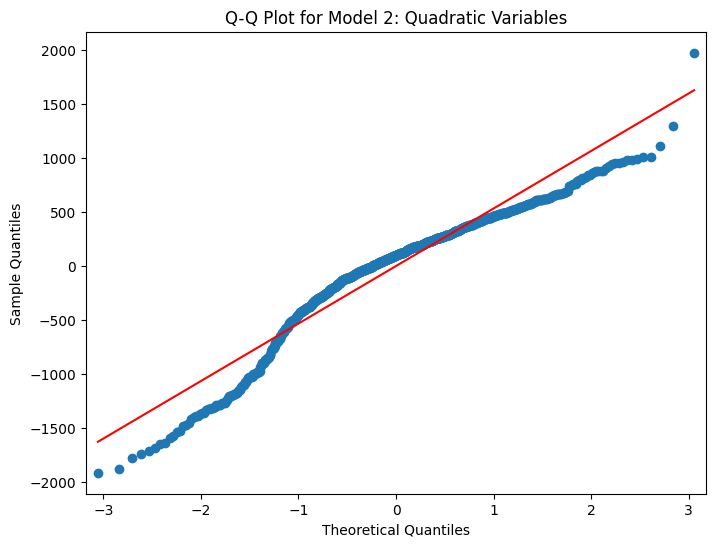

In [29]:
# Graphing it 
fig, ax = plt.subplots(figsize=(8,6))
sm.qqplot(model_2_fit.resid, ax=ax, line='s')
plt.title('Q-Q Plot for Model 2: Quadratic Variables')
plt.show()


Q-Q plot is deviating from the theoretical hytpothesis for the resdiduals, indicating that there is either a non-linear trend in our data, or there is non-constant variance (called heteroskedasticity) in our data (or there is both non-linear relationship and non-constant variance). Plot tells us that one of our modelling assumptions is invalidated. Lets just have a look at the residuals themselves.

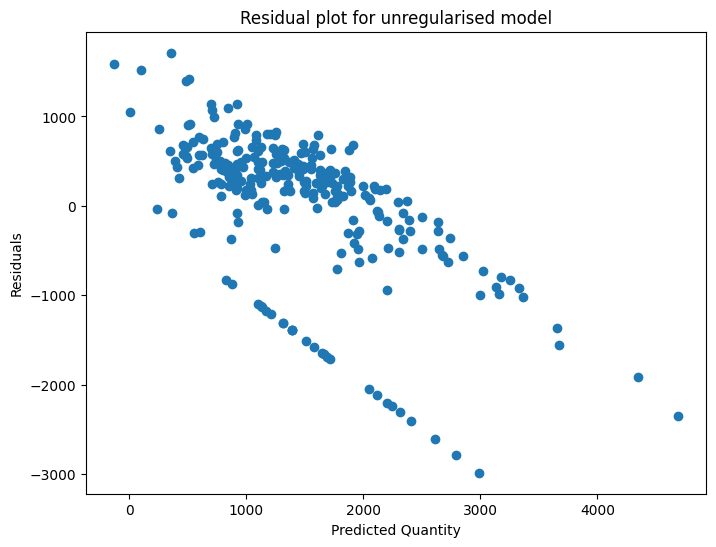

In [30]:
# Plotting the residuals
fig, ax = plt.subplots(figsize=(8,6))
plt.scatter(prediction_2_val, Y_val - prediction_2_val)
plt.title('Residual plot for unregularised model')
plt.xlabel('Predicted Quantity')
plt.ylabel('Residuals')
plt.show()

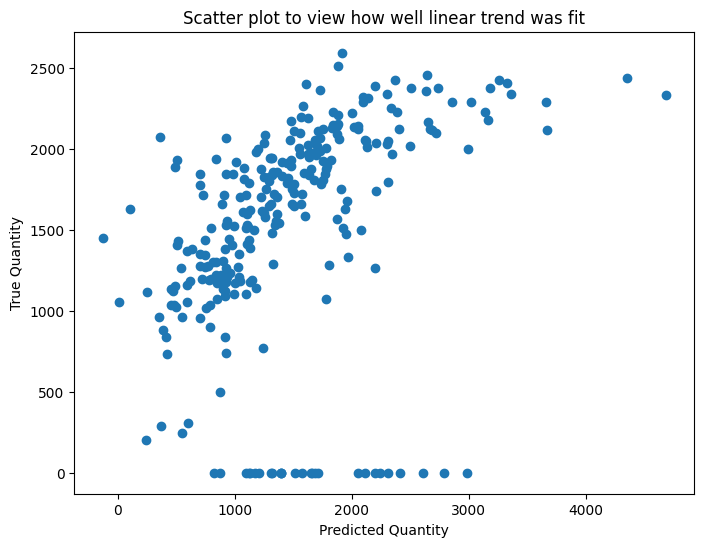

In [32]:
fig, ax = plt.subplots(figsize=(8,6))
plt.scatter(prediction_2_val, Y_val)
plt.title('Scatter plot to view how well linear trend was fit')
plt.xlabel('Predicted Quantity')
plt.ylabel('True Quantity')
plt.show()

STANDARDIZING DATA SET - SETTING DATA WITH A LARGE RANGE TO HAVE A MEAN OF 0 AND STD OF 1

In [ ]:
def standardise(data):
  """ Standardise/Normalise data to have zero mean and unit variance

  Args:
    data (np.array):
      data we want to standardise (usually covariates)

    Returns:
      Standardised data, mean of data, standard deviation of data
  """
  mu = np.mean(data, axis=0)
  sigma = np.std(data, axis=0)
  scaled = (data - mu) / sigma
  return scaled, mu, sigma

In [49]:
X_train_std, mu_train_x, sigma_train_x = standardise(X_train)
Y_train_std, mu_train_y, sigma_train_y = standardise(Y_train)

## Scaling the validation and Test set manually using the z score formula
## z = (x - mu)/sigma
## normal uncomplicated Data
X_val_std = (X_val - mu_train_x)/sigma_train_x
Y_val_std = (Y_val - mu_train_y)/sigma_train_y
X_test_std = (X_test - mu_train_x)/sigma_train_x
Y_test_std = (Y_test - mu_train_y)/sigma_train_y

# remove constant term - this is not needed with standardised data, and as a constant has a std.dev of 
# 0 will result is numeric issues if we leave it in
X_train_complex = np.delete(X_train_complex, 0, 1)
X_val_complex = np.delete(X_val_complex, 0, 1)
X_test_complex = np.delete(X_test_complex, 0, 1)

#Complicated data
X_train_complex_std, mu_train_complex_x, sigma_train_complex_x = standardise(X_train_complex)
X_val_complex_std = (X_val_complex - mu_train_complex_x)/sigma_train_complex_x
X_test_complex_std = (X_test_complex - mu_train_complex_x)/sigma_train_complex_x


### Step 2 (Question 1): Fit the Linear Model

Fit a linear model to your data. Fit a model to both the original (i.e. without higher order terms) and expanded versions of the data to observe how severe the overfitting is.

Be sure to evaluate the models on the validation and test sets. You should also consider qq-plots and $R^2$ values when inspecting the model's performance. To maximise code re-use, you may wish to write a function that takes a model, and various datasets (train, validation and test) as input, and calculates relevant performance measures. Some functions to compute performance measures are given below. Remember that $R^2$ should only be computed on the training set.

In [50]:
## LASSO REGRESSION (FEATURE SELECTION)
model_3 = sm.OLS(Y_train, X_train_complex)
model_3_fit = model_3.fit_regularized(alpha=10.0, L1_wt=1)
# to get L1 regression, need to set the L1_wt flag to 1 in the fit_regularzed method
pred = model_3_fit.predict(X_val_complex)
print('Model 3: L1 RMSE = {}'.format(
  np.sqrt(mean_squared_error(Y_val, pred))))
print(model_3_fit.params)

Model 3: L1 RMSE = 735.273624677056
[ 1.83284914e+01  4.36043904e+01  8.09279272e+00  1.96415217e-01
  1.49058318e+00  9.78651882e-01 -4.88204113e-01  2.33555975e-01
 -7.36554455e-01 -1.28414631e-01  9.60536786e-02  4.56589683e-03
  7.92244467e-03 -1.14650983e+00 -6.69594626e-02  4.33149565e-02
  3.33676790e-02 -2.45420961e-02 -3.73583652e-02  9.78789843e-02
  1.49251710e-04  2.18901287e-02 -1.32717609e-02 -1.91138365e-03
  9.06446248e-03 -1.86747188e-03 -3.33989738e-03  1.45468127e-03
 -4.49455533e-02 -4.49881961e-01 -2.61792715e-01  1.37030980e-03
  1.48604245e-02  7.33255329e-04  8.93826206e-04]


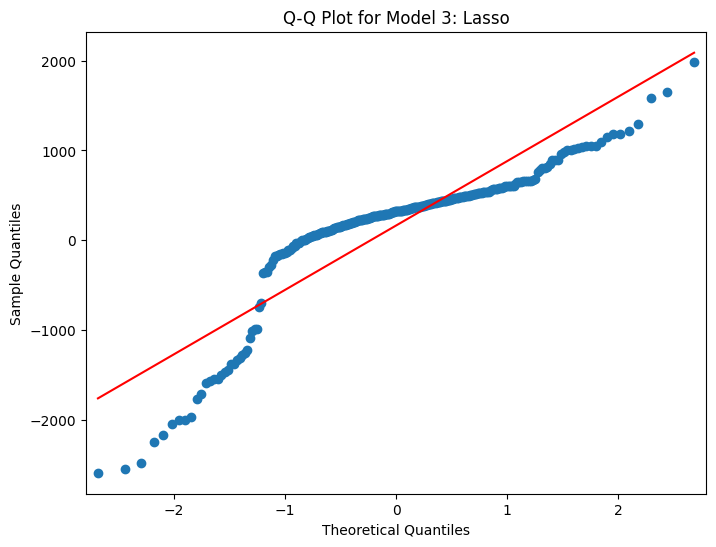

In [51]:
## RESIDS GRAPH
resid = Y_val - pred
fig, ax = plt.subplots(figsize=(8,6))
sm.qqplot(resid, ax=ax, line='s')
plt.title('Q-Q Plot for Model 3: Lasso')
plt.show()

 BADDDDD Not really good - lots of tailling since we only dropped one variable

Model 3: L1 RMSE = 797.5032280760662
[ 2.19386105e+00 -1.45160418e+00  2.41774180e+00  9.05703078e+00
  5.62672905e+00  2.06322190e+00 -1.33918370e+00  1.98091738e-01
 -1.46369828e-01 -5.28531482e-02  8.03618583e-02 -2.77322413e-03
 -4.87174164e-03 -5.85841132e-01  1.07376206e-01 -5.94280568e-01
  4.22969689e-02 -7.13139141e-02 -7.83197424e-01  1.47849693e-01
 -4.32602313e-03  1.10207596e-01  4.60969659e-02 -8.26178408e-03
  7.10744716e-03 -1.38467037e-02 -1.30852906e-02  2.79539977e-03
 -2.53763824e-02  1.70729355e+00  8.90484939e-02  2.07398658e-02
  5.36278271e-02  1.44362455e-03  1.37557087e-03]


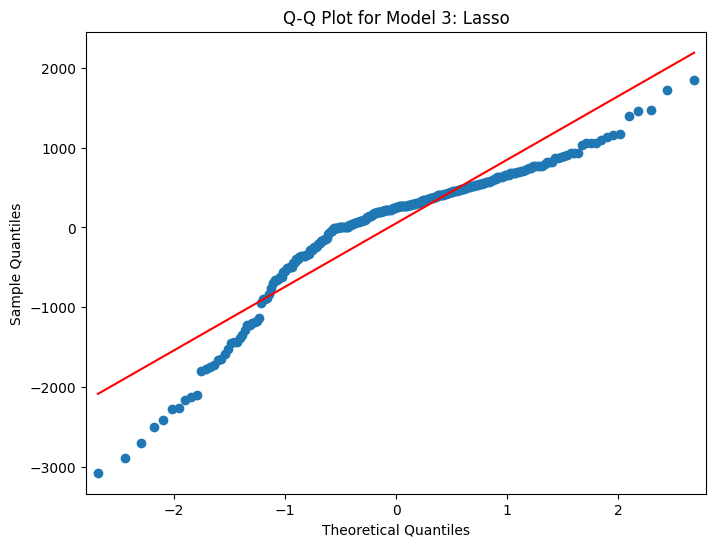

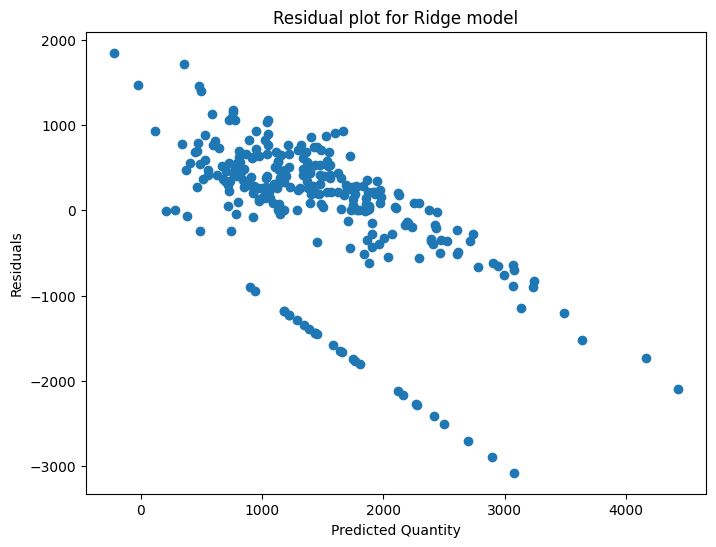

In [52]:
## RIDGE REGRESSION
model_4 = sm.OLS(Y_train, X_train_complex)
model_4_fit = model_4.fit_regularized(alpha=10.0, L1_wt=-0)
# to get L1 regression, need to set the L1_wt flag to 1 in the fit_regularzed method
pred = model_4_fit.predict(X_val_complex)
print('Model 3: L1 RMSE = {}'.format(
  np.sqrt(mean_squared_error(Y_val, pred))))
print(model_4_fit.params)

## Residuals graphs
resid = Y_val - pred
fig, ax = plt.subplots(figsize=(8,6))
sm.qqplot(resid, ax=ax, line='s')
plt.title('Q-Q Plot for Model 3: Lasso')
plt.show()

fig, ax = plt.subplots(figsize=(8,6))
plt.scatter(pred, resid)
plt.title('Residual plot for Ridge model')
plt.xlabel('Predicted Quantity')
plt.ylabel('Residuals')
plt.show()

In [4]:
def rmse(actual, pred):
  return np.sqrt(mean_squared_error(actual, pred))

def r_squared(actual, predicted):
  r2 = r2_score(actual, predicted)
  return r2

def adj_r2(actual, predicted, n, p):
  r2 = r2_score(actual, predicted)
  adjr2 = 1 - (1 - r2) * (n - 1) / (n - p - 1);
  return adjr2


### Step 3 (Question 2): Fit the Ridge Model

Fit a ridge model to your data.

It's recommended to use standardised data here, if you aren't already doing so.

The key consideration here is your value of $\lambda$. A good process to follow will be:
* Select a range of $\lambda$ values to consider. I would suggest using something like ``alpha_list = np.linspace(0, 10.0, 1000)``. Note that ``lambda`` is a keyword in python, hence we are calling this ``alpha`` here.
* Loop over the values of $\lambda$, i.e. ``for alpha in alpha_list:``
  * For each value of $\lambda$, fit a regression model
  * Get the RMSE on the validation set. You may also wish to compute:
    * RMSE on the training set
    * $R^$ on the training set
* Find the value of $\lambda$ that minimises the RMSE on the validation set

If your best value of $\lambda$ is $0$, you need to select a smaller step in your list of values, (i.e. in the above example we'd change this to ``alpha_list = np.linspace(0, 0.1, 10.0)``). If your best value is equal the maximum value in your range, then you need to search over a larger area (i.e. in the above example change it to ``alpha_list = np.linspace(0, 50.0, 10000)``). You may also want to refine your estimate, without making the search space huge. To do this, let's say the you get a value of $\lambda$ of 100, using the above ``linspace``. In this case you could search around the following: ``alpha_list = np.linspace(90.0, 0.1, 110.0)``.

Once you've found your value of $\lambda$, fit the final model, evaluate it as you did for the linear model, and compare the results.

### Step 4 (Question 3): Fit the LASSO Model

Fit a LASSO model to your data.

Your approach here should really follow what you've done for ridge. You should be able to copy and paste except:
* Change your range of $\lambda$ values. The same values that worked for Ridge will not be optimal here
* Change the regression function that you are calling. If you are using sklearn, this means swapping ``sklearn.linear_model.Ridge`` for ``sklearn.linear_model.Lasso``. If you are using statsmodels, this means that when you call ``fit_regularized`` you pass in ``L1_wt=1``.

Notes regarding $\lambda$ values as the same as for Ridge regression.

Once you have your final value of $\lambda$, evaluate the model and compare to the others.